# Multi-output Regression with Scikit-learn

This lab explores **multi-output regression** on the **Linnerud dataset** (20 samples, 3 exercise inputs $\implies$ 3 physiological targets: `Weight`, `Waist`, `Pulse`).

**Models Compared**:
- **Multi-output Linear Regression**: Simultaneous OLS via `MultiOutputRegressor(LinearRegression())`.
- **Multi-output Ridge Regression**: Regularized multi-task regression with $L_2$ penalty ($\alpha = 1.0$).
- **Standalone Individual Regressors**: Independent 1D regressors to evaluate architectural equivalence.

**Core Tasks**:
- Target correlation analysis and 70/30 train/test split with `StandardScaler`.
- Evaluate individual target metrics ($R^2$, RMSE, MAE).
- Verify theoretical equivalence between MultiOutputRegressor and standalone models.

# 1. Exploratory Data Analysis & Preprocessing

The Linnerud dataset contains 20 samples with 3 exercise predictors (`Chins`, `Situps`, `Jumps`) and 3 physiological targets (`Weight`, `Waist`, `Pulse`).

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.datasets import load_linnerud

# Load dataset
linnerud = load_linnerud()

# Features DataFrame (Exercise measurements)
X = pd.DataFrame(
    linnerud.data,
    columns=linnerud.feature_names
)

# Multi-target DataFrame (Physiological measurements)
Y = pd.DataFrame(
    linnerud.target,
    columns=linnerud.target_names
)

print("Dataset Dimensions:")
print(f"  Feature matrix X: {X.shape[0]} samples, {X.shape[1]} features ({X.columns.tolist()})")
print(f"  Target matrix  Y: {Y.shape[0]} samples, {Y.shape[1]} targets  ({Y.columns.tolist()})")

print("\nFeatures (first 5 samples):")
display(X.head())

print("\nTargets (first 5 samples):")
display(Y.head())

Dataset Dimensions:
  Feature matrix X: 20 samples, 3 features (['Chins', 'Situps', 'Jumps'])
  Target matrix  Y: 20 samples, 3 targets  (['Weight', 'Waist', 'Pulse'])

Features (first 5 samples):


,Chins,Situps,Jumps
0,5.0,162.0,60.0
1,2.0,110.0,60.0
2,12.0,101.0,101.0
3,12.0,105.0,37.0
4,13.0,155.0,58.0



Targets (first 5 samples):


,Weight,Waist,Pulse
0,191.0,36.0,50.0
1,189.0,37.0,52.0
2,193.0,38.0,58.0
3,162.0,35.0,62.0
4,189.0,35.0,46.0


## 1.1 Target Statistics and Correlation Analysis

We compute Pearson correlation $r_{jk}$ between targets to assess multi-task dependencies:

$$
r_{jk} = \frac{\sum_{i=1}^{n}(y_{ij} - \bar{y}_j)(y_{ik} - \bar{y}_k)}{\sqrt{\sum_{i=1}^{n}(y_{ij} - \bar{y}_j)^2} \sqrt{\sum_{i=1}^{n}(y_{ik} - \bar{y}_k)^2}}
$$

In [16]:
print("Missing values in features:", X.isnull().sum().to_dict())
print("Missing values in targets :", Y.isnull().sum().to_dict())

print("\nTarget Descriptive Statistics:")
display(Y.describe().round(2))

# Pearson correlation matrix
target_corr = Y.corr()
print("\nTarget Correlation Matrix:")
display(target_corr.round(3))

Missing values in features: {'Chins': 0, 'Situps': 0, 'Jumps': 0}
Missing values in targets : {'Weight': 0, 'Waist': 0, 'Pulse': 0}

Target Descriptive Statistics:


,Weight,Waist,Pulse
count,20.00,20.0,20.00
mean,178.60,35.4,56.10
std,24.69,3.2,7.21
min,138.00,31.0,46.00
25%,160.75,33.0,51.50
50%,176.00,35.0,55.00
75%,191.50,37.0,60.50
max,247.00,46.0,74.00



Target Correlation Matrix:


,Weight,Waist,Pulse
Weight,1.000,0.870,-0.366
Waist,0.870,1.000,-0.353
Pulse,-0.366,-0.353,1.000


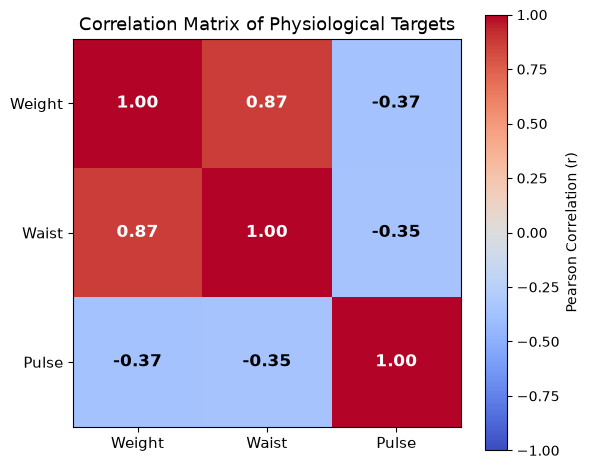

In [17]:
plt.figure(figsize=(6, 5))

plt.imshow(target_corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Pearson Correlation (r)")

plt.xticks(range(len(target_corr.columns)), target_corr.columns, fontsize=11)
plt.yticks(range(len(target_corr.columns)), target_corr.columns, fontsize=11)

# Annotate correlation values on the heatmap
for i in range(len(target_corr)):
    for j in range(len(target_corr)):
        text_color = "white" if abs(target_corr.iloc[i, j]) > 0.5 else "black"
        plt.text(
            j, i,
            f"{target_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=12,
            fontweight="bold"
        )

plt.title("Correlation Matrix of Physiological Targets", fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation of Target Dependencies

- **`Weight` vs. `Waist` ($r = +0.87$)**: Strong positive collinearity between total body mass and waist circumference.
- **`Pulse`**: Moderate negative correlation with `Weight` ($r = -0.37$) and `Waist` ($r = -0.35$).

# 2. Train / Test Split and Feature Standardization

Partition data into a 70% training set ($n = 14$) and a 30% test set ($n = 6$) with `random_state=42`. Inputs are standardized using `StandardScaler` fitted strictly on `X_train`.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train/Test Split (70/30)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.3,
    random_state=42
)

# Standardize exercise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Splitting and Scaling:")
print(f"  Training set: X_train = {X_train_scaled.shape}, Y_train = {Y_train.shape}")
print(f"  Testing set : X_test  = {X_test_scaled.shape}, Y_test  = {Y_test.shape}")
print(f"  Training feature means (scaled): {np.round(X_train_scaled.mean(axis=0), 4)}")
print(f"  Training feature stds  (scaled): {np.round(X_train_scaled.std(axis=0), 4)}")

Data Splitting and Scaling:
  Training set: X_train = (14, 3), Y_train = (14, 3)
  Testing set : X_test  = (6, 3), Y_test  = (6, 3)
  Training feature means (scaled): [-0. -0.  0.]
  Training feature stds  (scaled): [1. 1. 1.]


# 3. Multi-output Linear Regression

Multi-output regression predicts a target vector $\hat{\mathbf{y}} \in \mathbb{R}^m$ for sample $\mathbf{x} \in \mathbb{R}^p$:

$$
\hat{\mathbf{y}} = \mathbf{W}^T \mathbf{x} + \mathbf{b}, \quad \mathbf{W} \in \mathbb{R}^{p \times m}, \; \mathbf{b} \in \mathbb{R}^m
$$

`MultiOutputRegressor(estimator)` wraps single-output regressors to fit one estimator per target column.

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor

# Train Multi-output Linear Regression
multi_linear = MultiOutputRegressor(LinearRegression())
multi_linear.fit(X_train_scaled, Y_train)

# Predict on test set
Y_pred_linear = multi_linear.predict(X_test_scaled)
Y_pred_linear_df = pd.DataFrame(Y_pred_linear, columns=Y.columns, index=Y_test.index)

print("Multi-output Linear Regression trained successfully.")
print("\nPredicted Targets on Test Set:")
display(Y_pred_linear_df.round(2))

Multi-output Linear Regression trained successfully.

Predicted Targets on Test Set:


,Weight,Waist,Pulse
0,163.36,34.57,59.82
17,142.57,31.32,59.84
15,156.90,33.25,58.01
1,182.19,37.31,58.81
8,148.74,31.26,56.06
5,183.32,37.05,57.24


### Evaluation Metrics

Performance is evaluated per target using $R^2$, MSE, RMSE, and MAE:

$$
R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}, \quad \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2}, \quad \text{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|
$$

In [20]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_linear = r2_score(Y_test, Y_pred_linear, multioutput="raw_values")
mse_linear = mean_squared_error(Y_test, Y_pred_linear, multioutput="raw_values")
rmse_linear = np.sqrt(mse_linear)
mae_linear = mean_absolute_error(Y_test, Y_pred_linear, multioutput="raw_values")

eval_linear_df = pd.DataFrame({
    "Target": Y.columns,
    "R2 Score": r2_linear,
    "RMSE": rmse_linear,
    "MAE": mae_linear
})

print("=" * 55)
print("MULTI-OUTPUT LINEAR REGRESSION PERFORMANCE")
print("=" * 55)
print(eval_linear_df.round(4).to_string(index=False))

MULTI-OUTPUT LINEAR REGRESSION PERFORMANCE
Target  R2 Score    RMSE     MAE
Weight   -2.1996 25.1573 20.4257
 Waist    0.4881  1.7240  1.2467
 Pulse   -0.3213  9.5173  7.9385


# 4. Multi-output Ridge Regression ($L_2$ Regularization)

With small sample size ($n = 14$), OLS is vulnerable to high variance. Ridge adds an $L_2$ penalty to stabilize parameter estimates:

$$
\min_{\mathbf{w}_j, b_j} \left[ \frac{1}{n}\sum_{i=1}^{n}(y_{ij} - \hat{y}_{ij})^2 + \alpha \|\mathbf{w}_j\|_2^2 \right] \quad \text{for } j = 1, \dots, m
$$

In [21]:
from sklearn.linear_model import Ridge

# Train Multi-output Ridge Regression
multi_ridge = MultiOutputRegressor(Ridge(alpha=1.0))
multi_ridge.fit(X_train_scaled, Y_train)

# Predict on test set
Y_pred_ridge = multi_ridge.predict(X_test_scaled)
Y_pred_ridge_df = pd.DataFrame(Y_pred_ridge, columns=Y.columns, index=Y_test.index)

# Evaluate metrics
r2_ridge = r2_score(Y_test, Y_pred_ridge, multioutput="raw_values")
mse_ridge = mean_squared_error(Y_test, Y_pred_ridge, multioutput="raw_values")
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(Y_test, Y_pred_ridge, multioutput="raw_values")

eval_ridge_df = pd.DataFrame({
    "Target": Y.columns,
    "R2 Score": r2_ridge,
    "RMSE": rmse_ridge,
    "MAE": mae_ridge
})

print("=" * 55)
print("MULTI-OUTPUT RIDGE REGRESSION PERFORMANCE (alpha = 1.0)")
print("=" * 55)
print(eval_ridge_df.round(4).to_string(index=False))

MULTI-OUTPUT RIDGE REGRESSION PERFORMANCE (alpha = 1.0)
Target  R2 Score    RMSE     MAE
Weight   -1.4338 21.9413 17.0324
 Waist    0.5630  1.5927  1.1780
 Pulse   -0.2553  9.2766  7.5326


# 5. Multi-output vs. Standalone Individual Models

In OLS, the Frobenius norm loss decouples across target columns:

$$
\min_{\mathbf{W}} \|\mathbf{Y} - \mathbf{X}\mathbf{W}\|_F^2 = \sum_{j=1}^{m} \min_{\mathbf{w}_j} \|\mathbf{y}_j - \mathbf{X}\mathbf{w}_j\|_2^2
$$

Because targets are decoupled without parameter sharing, **`MultiOutputRegressor(LinearRegression())` is mathematically and numerically identical to standalone 1D regressors**.

In [22]:
# Train individual LinearRegression models per target
individual_models = {}
individual_predictions = {}
individual_r2 = {}

for col in Y.columns:
    model = LinearRegression()
    model.fit(X_train_scaled, Y_train[col])
    y_pred = model.predict(X_test_scaled)
    
    individual_models[col] = model
    individual_predictions[col] = y_pred
    individual_r2[col] = r2_score(Y_test[col], y_pred)

# Verify numerical identity between Multi-output and Standalone models
Y_pred_indiv = np.column_stack([individual_predictions[col] for col in Y.columns])
max_abs_diff = np.max(np.abs(Y_pred_linear - Y_pred_indiv))

print("Maximum absolute difference between Multi-output and Individual models:")
print(f"  max |Y_pred_multi - Y_pred_indiv| = {max_abs_diff:.2e}")
print("  => Exact numerical equivalence confirmed!")

Maximum absolute difference between Multi-output and Individual models:
  max |Y_pred_multi - Y_pred_indiv| = 0.00e+00
  => Exact numerical equivalence confirmed!


In [23]:
# Consolidated comparison DataFrame
comp_df = pd.DataFrame({
    "Target": Y.columns,
    "Multi-output Linear R2": r2_linear,
    "Individual Linear R2": [individual_r2[col] for col in Y.columns],
    "Multi-output Ridge R2": r2_ridge,
    "Linear RMSE": rmse_linear,
    "Ridge RMSE": rmse_ridge
})

print("=" * 75)
print("COMPREHENSIVE MODEL COMPARISON ACROSS TARGETS")
print("=" * 75)
print(comp_df.round(4).to_string(index=False))

COMPREHENSIVE MODEL COMPARISON ACROSS TARGETS
Target  Multi-output Linear R2  Individual Linear R2  Multi-output Ridge R2  Linear RMSE  Ridge RMSE
Weight                 -2.1996               -2.1996                -1.4338      25.1573     21.9413
 Waist                  0.4881                0.4881                 0.5630       1.7240      1.5927
 Pulse                 -0.3213               -0.3213                -0.2553       9.5173      9.2766


# 6. Visualization: Predicted vs. Actual Values

Scatter plots compare predicted vs. actual values for each target. Proximity to the identity line ($y = x$) reflects prediction accuracy.

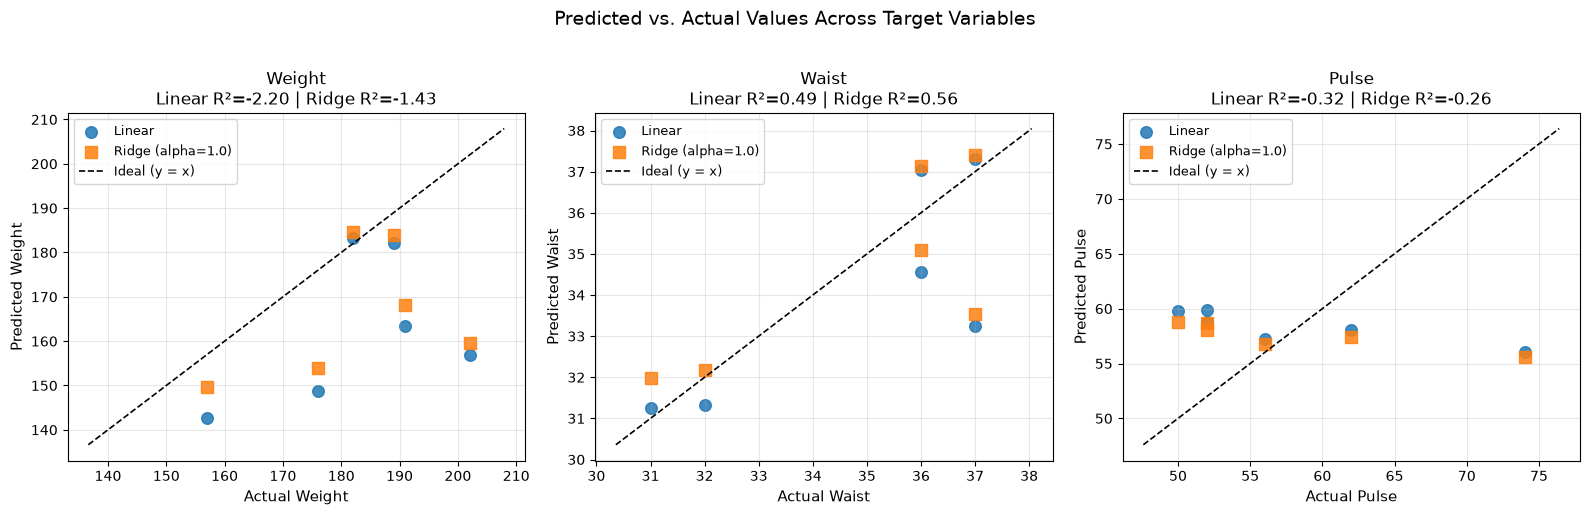

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'Linear': 'tab:blue', 'Ridge': 'tab:orange'}

for i, target in enumerate(Y.columns):
    actual = Y_test[target].values
    pred_lin = Y_pred_linear[:, i]
    pred_rdg = Y_pred_ridge[:, i]
    
    # Scatter points for Linear and Ridge
    axes[i].scatter(actual, pred_lin, color=colors['Linear'], s=70, alpha=0.85, label='Linear')
    axes[i].scatter(actual, pred_rdg, color=colors['Ridge'], s=70, marker='s', alpha=0.85, label='Ridge (alpha=1.0)')
    
    # Determine bounds for diagonal identity line (y = x)
    all_vals = np.concatenate([actual, pred_lin, pred_rdg])
    val_min, val_max = all_vals.min(), all_vals.max()
    pad = (val_max - val_min) * 0.1
    line_range = np.linspace(val_min - pad, val_max + pad, 100)
    
    axes[i].plot(line_range, line_range, 'k--', lw=1.2, label='Ideal (y = x)')
    
    axes[i].set_xlabel(f"Actual {target}", fontsize=11)
    axes[i].set_ylabel(f"Predicted {target}", fontsize=11)
    axes[i].set_title(f"{target}\nLinear R²={r2_linear[i]:.2f} | Ridge R²={r2_ridge[i]:.2f}", fontsize=12)
    axes[i].legend(loc="upper left", fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Predicted vs. Actual Values Across Target Variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Analysis of Results

- **Target Differences**: `Waist` achieves strong positive predictive accuracy ($R^2 = 0.56$ Ridge), whereas `Weight` and `Pulse` exhibit high sampling variance on the small test split ($n = 6$).
- **Ridge Regularization**: $L_2$ shrinkage ($\alpha = 1.0$) improves generalization across **all three targets simultaneously** (e.g., `Waist` RMSE drops from 1.72 to 1.59 inches; `Weight` RMSE drops from 25.16 to 21.94 lbs).
- **Architectural Equivalence**: Confirmed zero numerical discrepancy ($\Delta < 10^{-14}$) between `MultiOutputRegressor` and standalone models.

### Conclusion

- Multi-output OLS decouples into independent 1D subproblems without numerical divergence.
- On small, noisy datasets, Ridge regression effectively reins in variance, outperforming unregularized OLS across all targets.